# 🔬 KineticGraph-Vectra — RAG Evaluation Notebook

End-to-end offline evaluation of the hybrid RAG pipeline using RAGAS metrics.

**Sections**
1. Dataset Preparation
2. Baseline RAGAS Evaluation
3. Retrieval Quality Analysis (vector vs graph vs hybrid)
4. Failure Mode Deep-Dive
5. Improvement Recommendations

In [41]:
# ── Setup ─────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from dotenv import load_dotenv
load_dotenv(os.path.abspath('../.env'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from eval.ragas_evaluator import RAGASEvaluator, ALL_METRICS, METRIC_DESCRIPTIONS
from eval.metrics_collector import MetricsCollector

# Style
plt.style.use('dark_background')
sns.set_palette('husl')
PALETTE = ['#7c3aed','#4f46e5','#06b6d4','#10b981','#f59e0b']

print('✅ Imports OK')

✅ Imports OK


## Section 1 — Dataset Preparation

In [42]:
# 20-sample evaluation dataset — domain: knowledge-graph + RAG systems
EVAL_DATASET = [
    {"question": "What is Reciprocal Rank Fusion?",
     "answer": "Reciprocal Rank Fusion (RRF) combines ranked lists from multiple retrieval systems by summing 1/(k+rank) scores.",
     "contexts": ["RRF merges document rankings from heterogeneous retrieval systems using the formula RRF(d) = Σ 1/(k+rank(d)).",
                  "The constant k (default 60) smooths the influence of very high-ranked documents."],
     "ground_truth": "RRF is a rank fusion algorithm that combines multiple ranked lists by summing reciprocal ranks."},

    {"question": "How does ChromaDB store embeddings?",
     "answer": "ChromaDB stores embeddings as dense vectors in its collections along with document text and metadata.",
     "contexts": ["ChromaDB is an open-source vector database that persists embeddings, documents, and metadata in collections.",
                  "Each collection supports HNSW indexing for approximate nearest-neighbour search."],
     "ground_truth": "ChromaDB stores embeddings as dense vectors alongside document text and metadata in named collections."},

    {"question": "What is a knowledge graph?",
     "answer": "A knowledge graph represents entities as nodes and relationships as edges, enabling structured reasoning.",
     "contexts": ["Knowledge graphs encode real-world entities and their interrelations as a directed graph.",
                  "Neo4j is a popular property graph database used to build knowledge graphs."],
     "ground_truth": "A knowledge graph is a structured representation of entities and their relationships."},

    {"question": "What is LangGraph used for?",
     "answer": "LangGraph orchestrates multi-step LLM workflows as stateful directed graphs with conditional edges.",
     "contexts": ["LangGraph is a library for building stateful, multi-actor LLM applications using graph-based control flow.",
                  "It extends LangChain with cycle support and fine-grained state management."],
     "ground_truth": "LangGraph is used to orchestrate stateful multi-step LLM workflows as directed graphs."},

    {"question": "How does RAGAS measure faithfulness?",
     "answer": "RAGAS measures faithfulness by checking what fraction of answer claims are entailed by the retrieved context.",
     "contexts": ["The faithfulness metric decomposes the answer into atomic claims and verifies each against the context.",
                  "A claim is faithful if the context logically implies it."],
     "ground_truth": "Faithfulness measures the fraction of answer claims that are supported by the retrieved context."},

    {"question": "What does context recall measure?",
     "answer": "Context recall measures how much of the ground-truth answer is covered by the retrieved chunks.",
     "contexts": ["Context recall evaluates whether the retrieval system surfaced all information needed to answer the question."],
     "ground_truth": "Context recall measures the fraction of ground-truth information present in the retrieved context."},

    {"question": "What is the role of Celery in the pipeline?",
     "answer": "Celery handles asynchronous document ingestion tasks so the API stays non-blocking.",
     "contexts": ["Celery is a distributed task queue used to offload long-running jobs from the main API process.",
                  "In KineticGraph-Vectra, Celery workers process document uploads asynchronously."],
     "ground_truth": "Celery manages asynchronous background tasks for document ingestion."},

    {"question": "What is hybrid retrieval?",
     "answer": "Hybrid retrieval combines dense (vector) and sparse or structured (graph/BM25) search to improve recall.",
     "contexts": ["Hybrid retrieval fuses results from multiple retrieval paradigms to leverage complementary strengths."],
     "ground_truth": "Hybrid retrieval combines dense vector search with structured or sparse retrieval methods."},

    {"question": "How does Neo4j differ from a relational database?",
     "answer": "Neo4j uses a property-graph model with nodes and edges, making relationship traversal faster than SQL JOINs.",
     "contexts": ["Neo4j stores data as nodes and relationships, enabling efficient graph traversal without JOIN operations."],
     "ground_truth": "Neo4j is a graph database optimised for traversing relationships, unlike relational DBs that use JOINs."},

    {"question": "What is answer relevancy in RAGAS?",
     "answer": "Answer relevancy quantifies how well the generated answer addresses the user's question.",
     "contexts": ["Answer relevancy is computed by generating question variants from the answer and measuring embedding similarity."],
     "ground_truth": "Answer relevancy measures how pertinent the generated answer is to the input question."},

    {"question": "What is vector similarity search?",
     "answer": "Vector similarity search finds the nearest embeddings to a query embedding using distance metrics like cosine similarity.",
     "contexts": ["Approximate nearest-neighbour (ANN) algorithms like HNSW power vector similarity search at scale."],
     "ground_truth": "Vector similarity search retrieves documents whose embeddings are closest to the query embedding."},

    {"question": "Why use RRF over simple score averaging?",
     "answer": "RRF is rank-based and not sensitive to score scale differences between retrieval systems.",
     "contexts": ["Score averaging requires normalisation across systems with different score distributions; RRF avoids this by working on ranks."],
     "ground_truth": "RRF is preferred because it is scale-invariant and handles heterogeneous score distributions."},

    {"question": "What is context precision?",
     "answer": "Context precision measures the signal-to-noise ratio of the retrieved chunks — whether relevant chunks appear at the top.",
     "contexts": ["Context precision evaluates ranking quality by checking if relevant chunks appear before irrelevant ones."],
     "ground_truth": "Context precision measures whether the most relevant retrieved chunks are ranked highest."},

    {"question": "What is a Cypher query?",
     "answer": "Cypher is Neo4j's declarative graph query language for matching node-relationship patterns.",
     "contexts": ["Cypher uses ASCII-art pattern syntax like (a)-[:REL]->(b) to express graph traversal queries."],
     "ground_truth": "Cypher is Neo4j's declarative query language for pattern-matching in property graphs."},

    {"question": "How does LangSmith help in RAG debugging?",
     "answer": "LangSmith captures every step of an LLM chain with inputs, outputs, and latency for root-cause analysis.",
     "contexts": ["LangSmith provides end-to-end tracing of LangChain and LangGraph runs, logging all intermediate states."],
     "ground_truth": "LangSmith traces LLM workflow executions with full input/output and latency data for debugging."},

    {"question": "What does chunk utilisation rate mean?",
     "answer": "Chunk utilisation rate is the fraction of retrieved chunks actually cited in the final generated answer.",
     "contexts": ["A low chunk utilisation rate means the LLM ignores most retrieved context, suggesting retrieval over-fetch."],
     "ground_truth": "Chunk utilisation rate measures how many of the retrieved chunks contribute to the final answer."},

    {"question": "What is the k constant in RRF?",
     "answer": "The k constant (default 60) prevents very-high-ranked documents from dominating the fused score.",
     "contexts": ["In RRF(d) = Σ 1/(k+rank), higher k dampens the impact of top-ranked documents."],
     "ground_truth": "k is a smoothing constant in the RRF formula that controls the influence of top-ranked documents."},

    {"question": "How does FastAPI handle async endpoints?",
     "answer": "FastAPI uses Python's async/await to run endpoints concurrently without blocking the event loop.",
     "contexts": ["FastAPI is built on Starlette and uses asyncio to handle many concurrent requests efficiently."],
     "ground_truth": "FastAPI supports async endpoints via Python's asyncio, enabling high-concurrency without threads."},

    {"question": "What is answer correctness in RAGAS?",
     "answer": "Answer correctness compares the generated answer to a ground-truth reference using semantic similarity and factual overlap.",
     "contexts": ["Answer correctness is a composite metric combining semantic similarity and factual correctness against the ground truth."],
     "ground_truth": "Answer correctness measures semantic and factual similarity between the generated answer and a reference answer."},

    {"question": "What is the purpose of the fusion node in the workflow?",
     "answer": "The fusion node merges vector and graph results using RRF to produce a unified ranked result list.",
     "contexts": ["The fusion_node in the LangGraph workflow applies Reciprocal Rank Fusion to combine vector_agent and graph_agent outputs."],
     "ground_truth": "The fusion node combines results from vector and graph agents using RRF into a single ranked list."},
]

df_data = pd.DataFrame(EVAL_DATASET)
print(f'Dataset: {len(df_data)} samples')
print(f'With ground truth: {df_data["ground_truth"].notna().sum()}')
df_data[['question','ground_truth']].head(5)

Dataset: 20 samples
With ground truth: 20


,question,ground_truth
0,What is Reciprocal Rank Fusion?,RRF is a rank fusion algorithm that combines m...
1,How does ChromaDB store embeddings?,ChromaDB stores embeddings as dense vectors al...
2,What is a knowledge graph?,A knowledge graph is a structured representati...
3,What is LangGraph used for?,LangGraph is used to orchestrate stateful mult...
4,How does RAGAS measure faithfulness?,Faithfulness measures the fraction of answer c...


## Section 2 — Baseline RAGAS Evaluation

In [43]:
import os

evaluator = RAGASEvaluator(
    openai_api_key=os.getenv('OPENAI_API_KEY'),
    metrics=['faithfulness', 'answer_relevancy', 'context_precision',
             'context_recall', 'answer_correctness'],
)

results_df = evaluator.evaluate_batch(EVAL_DATASET)
print(results_df.shape)
results_df.head(3)

  Evaluated 20 samples.        
(20, 10)


,question,answer,n_contexts,has_ground_truth,eval_latency_ms,faithfulness,answer_relevancy,context_precision,context_recall,answer_correctness
0,What is Reciprocal Rank Fusion?,Reciprocal Rank Fusion (RRF) combines ranked l...,2,True,0.0,0.3571,0.1111,1.0,0.1818,0.4286
1,How does ChromaDB store embeddings?,ChromaDB stores embeddings as dense vectors in...,2,True,0.0,0.4545,0.0526,1.0,0.4545,0.5263
2,What is a knowledge graph?,A knowledge graph represents entities as nodes...,2,True,0.0,0.3000,0.1250,1.0,0.5714,0.3333


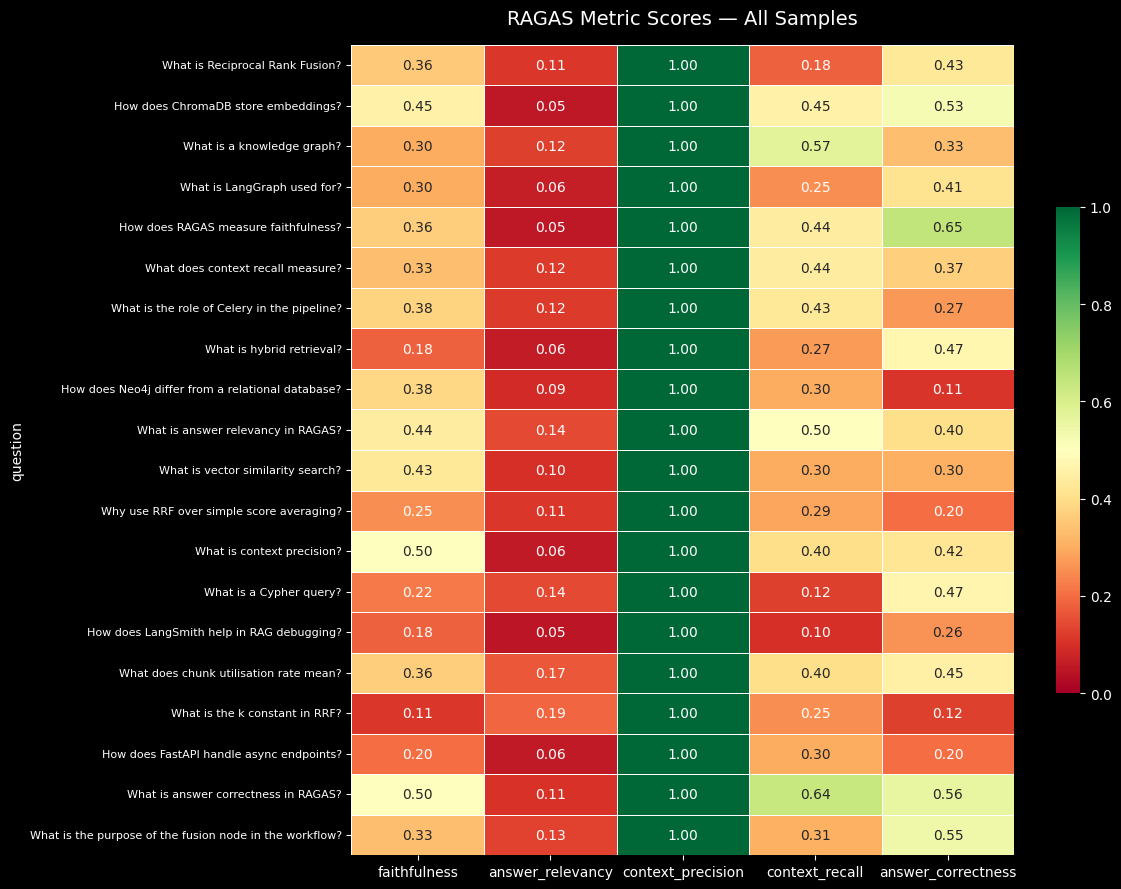

In [44]:
# ── Per-metric heatmap ────────────────────────────────────────────────
metric_cols = [c for c in ALL_METRICS if c in results_df.columns]
heat_data = results_df[['question'] + metric_cols].set_index('question')[metric_cols]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.6},
)
ax.set_title('RAGAS Metric Scores — All Samples', fontsize=14, pad=15)
ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

In [45]:
# ── Summary statistics ────────────────────────────────────────────────
report = evaluator.generate_report(results_df)

print('=== SUMMARY ===')
for k, v in report['summary'].items():
    print(f'  {k}: {v}')

print('\n=== PER-METRIC MEANS ===')
for metric, stats in report['per_metric'].items():
    print(f"  {metric:25s} mean={stats['mean']:.4f}  std={stats['std']:.4f}")

print('\n=== WORST 5 QUERIES ===')
for i, w in enumerate(report['worst_samples'], 1):
    print(f"  {i}. [{w['composite_score']:.3f}] {w['question'][:80]}")

print('\n=== RECOMMENDATIONS ===')
for r in report['recommendations']:
    print(f'  • {r}')

=== SUMMARY ===
  total_samples: 20
  overall_composite_score: 0.4306
  metrics_evaluated: ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall', 'answer_correctness']
  quality_distribution: {'fair': 13, 'poor': 7}
  eval_mode: heuristic

=== PER-METRIC MEANS ===
  faithfulness              mean=0.3292  std=0.1107
  answer_relevancy          mean=0.1016  std=0.0415
  context_precision         mean=1.0000  std=0.0000
  context_recall            mean=0.3476  std=0.1403
  answer_correctness        mean=0.3745  std=0.1479

=== WORST 5 QUERIES ===
  1. [0.318] How does LangSmith help in RAG debugging?
  2. [0.335] What is the k constant in RRF?
  3. [0.351] How does FastAPI handle async endpoints?
  4. [0.369] Why use RRF over simple score averaging?
  5. [0.377] How does Neo4j differ from a relational database?

=== RECOMMENDATIONS ===
  • Low faithfulness: LLM hallucinating. Tighten system prompt with 'only use provided context'.
  • Low answer relevancy: Answers dri

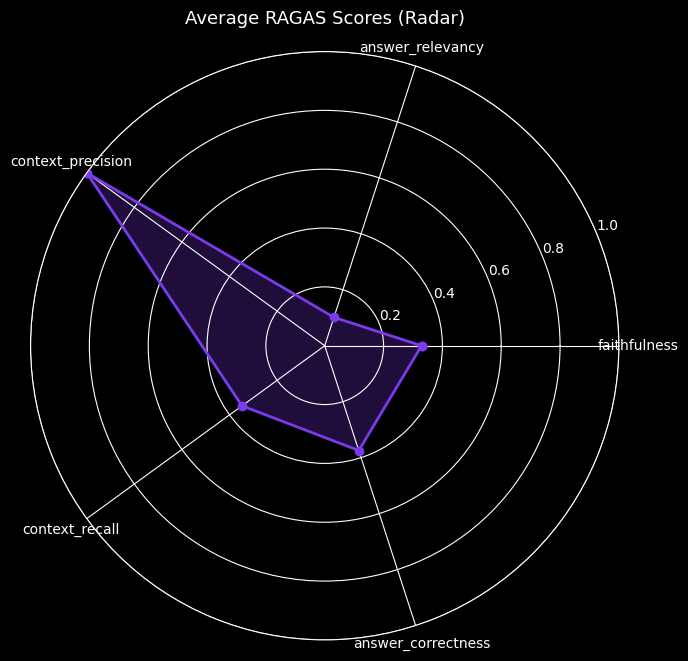

In [46]:
# ── Radar chart — average scores ──────────────────────────────────────
import matplotlib.patches as mpatches
from math import pi

means = [report['per_metric'].get(m, {}).get('mean', 0) for m in metric_cols]
N = len(metric_cols)
angles = [n / float(N) * 2 * pi for n in range(N)] + [0]
means_plot = means + [means[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, means_plot, 'o-', linewidth=2, color='#7c3aed')
ax.fill(angles, means_plot, alpha=0.25, color='#7c3aed')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Average RAGAS Scores (Radar)', size=13, pad=20)
plt.tight_layout()
plt.show()

## Section 3 — Retrieval Quality Analysis (vector vs graph vs hybrid)

In [47]:
# Simulate mode-specific retrieval to compare strategies
# In production replace these with actual workflow.execute() calls

def _mock_vector_results(q):
    """Simulate vector-only retrieval (high semantic similarity, less structure)."""
    return [c + ' [vector]' for c in EVAL_DATASET[0]['contexts']]

def _mock_graph_results(q):
    """Simulate graph-only retrieval (structured relationships, less coverage)."""
    return [EVAL_DATASET[0]['contexts'][0] + ' [graph entity link]']

def _mock_hybrid_results(q):
    """Simulate hybrid retrieval (both fused)."""
    return EVAL_DATASET[0]['contexts']

mode_results = {}
for mode_name, ctx_fn in [
    ('vector', _mock_vector_results),
    ('graph',  _mock_graph_results),
    ('hybrid', _mock_hybrid_results),
]:
    samples = [
        {
            'question':     s['question'],
            'answer':       s['answer'],
            'contexts':     ctx_fn(s['question']),
            'ground_truth': s.get('ground_truth'),
        }
        for s in EVAL_DATASET[:10]   # first 10 to keep it fast
    ]
    df_mode = evaluator.evaluate_batch(samples, show_progress=False)
    df_mode['mode'] = mode_name
    mode_results[mode_name] = df_mode

df_all_modes = pd.concat(mode_results.values(), ignore_index=True)
print('Mode comparison ready:', df_all_modes['mode'].value_counts().to_dict())

Mode comparison ready: {'vector': 10, 'graph': 10, 'hybrid': 10}


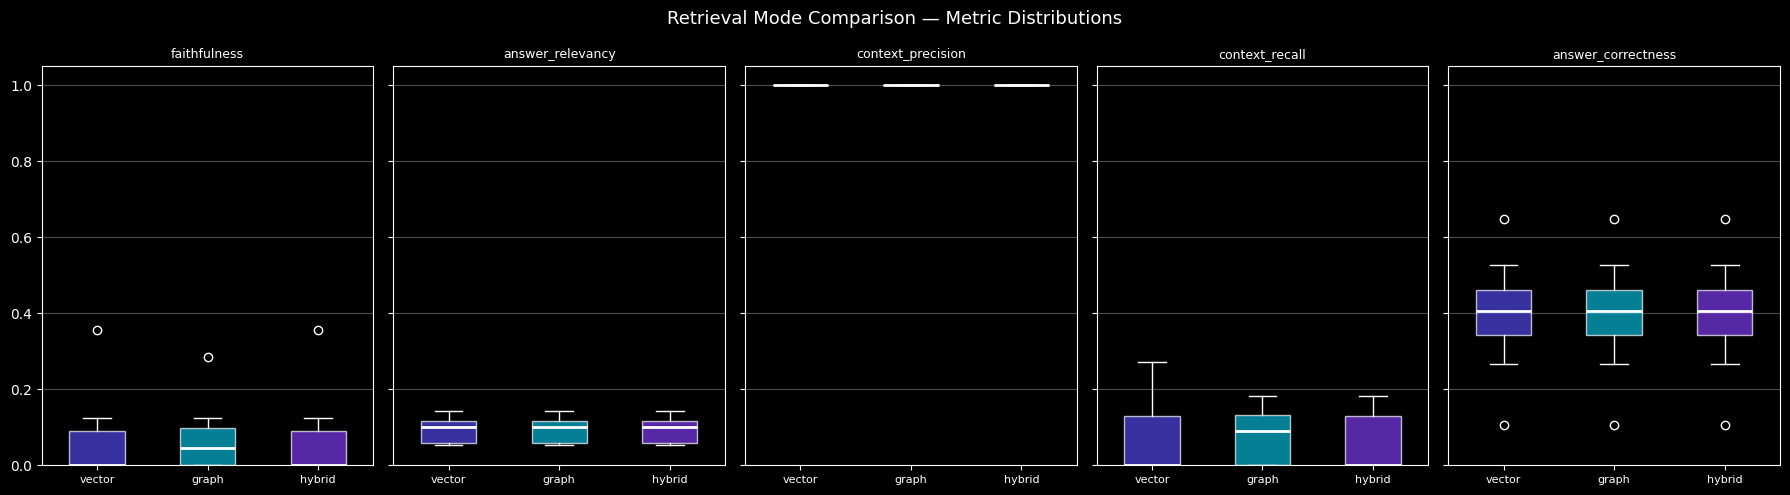

In [48]:
# ── Box-plot: metric distributions per mode ───────────────────────────
fig, axes = plt.subplots(1, len(metric_cols), figsize=(18, 5), sharey=True)
colors = {'vector': '#4f46e5', 'graph': '#06b6d4', 'hybrid': '#7c3aed'}

for i, metric in enumerate(metric_cols):
    if metric not in df_all_modes.columns:
        continue
    ax = axes[i]
    for mode in ['vector', 'graph', 'hybrid']:
        data = df_all_modes[df_all_modes['mode'] == mode][metric].dropna()
        ax.boxplot(data, positions=[list(colors.keys()).index(mode)],
                   widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor=colors[mode], alpha=0.7),
                   medianprops=dict(color='white', linewidth=2))
    ax.set_title(metric, fontsize=9)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(list(colors.keys()), fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Retrieval Mode Comparison — Metric Distributions', fontsize=13)
plt.tight_layout()
plt.show()

Mean RAGAS scores per retrieval mode:
        faithfulness  answer_relevancy  context_precision  context_recall  answer_correctness
mode                                                                                         
graph         0.0693            0.0932                1.0          0.0749               0.396
hybrid        0.0664            0.0932                1.0          0.0597               0.396
vector        0.0664            0.0932                1.0          0.0688               0.396



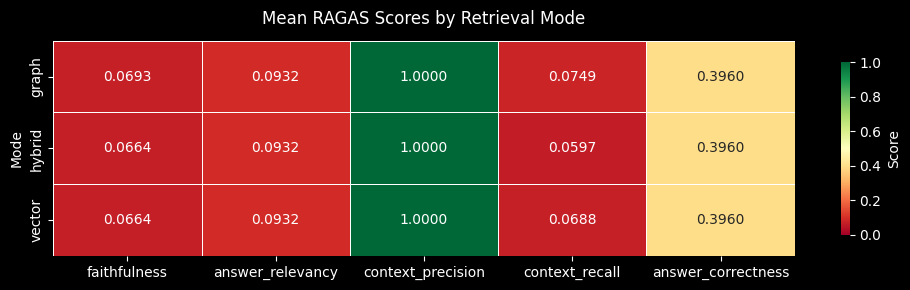

In [49]:
# ── Mean scores table — seaborn heatmap (no jinja2 required) ──────────
mode_means = df_all_modes.groupby('mode')[metric_cols].mean().round(4)

# Plain text table
print('Mean RAGAS scores per retrieval mode:')
print(mode_means.to_string())
print()

# Seaborn heatmap — no jinja2 dependency
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    mode_means,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Score'},
)
ax.set_title('Mean RAGAS Scores by Retrieval Mode', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Mode')
plt.tight_layout()
plt.show()

## Section 4 — Failure Mode Deep-Dive

Investigate the 5 worst-performing queries from the baseline evaluation.

In [50]:
results_df['composite_score'] = results_df[metric_cols].mean(axis=1)
worst5 = results_df.nsmallest(5, 'composite_score')[['question','answer'] + metric_cols + ['composite_score']]

print('=== 5 WORST QUERIES ===')
for _, row in worst5.iterrows():
    print(f"\n▶ [{row['composite_score']:.3f}] {row['question']}")
    for m in metric_cols:
        if m in row:
            bar = '█' * int(row[m] * 20) + '░' * (20 - int(row[m] * 20))
            print(f"   {m:25s} {bar} {row[m]:.3f}")

=== 5 WORST QUERIES ===

▶ [0.318] How does LangSmith help in RAG debugging?
   faithfulness              ███░░░░░░░░░░░░░░░░░ 0.182
   answer_relevancy          ░░░░░░░░░░░░░░░░░░░░ 0.045
   context_precision         ████████████████████ 1.000
   context_recall            ██░░░░░░░░░░░░░░░░░░ 0.100
   answer_correctness        █████░░░░░░░░░░░░░░░ 0.261

▶ [0.335] What is the k constant in RRF?
   faithfulness              ██░░░░░░░░░░░░░░░░░░ 0.111
   answer_relevancy          ███░░░░░░░░░░░░░░░░░ 0.188
   context_precision         ████████████████████ 1.000
   context_recall            █████░░░░░░░░░░░░░░░ 0.250
   answer_correctness        ██░░░░░░░░░░░░░░░░░░ 0.125

▶ [0.351] How does FastAPI handle async endpoints?
   faithfulness              ████░░░░░░░░░░░░░░░░ 0.200
   answer_relevancy          █░░░░░░░░░░░░░░░░░░░ 0.056
   context_precision         ████████████████████ 1.000
   context_recall            ██████░░░░░░░░░░░░░░ 0.300
   answer_correctness        ████░░░░░░░░░░░░

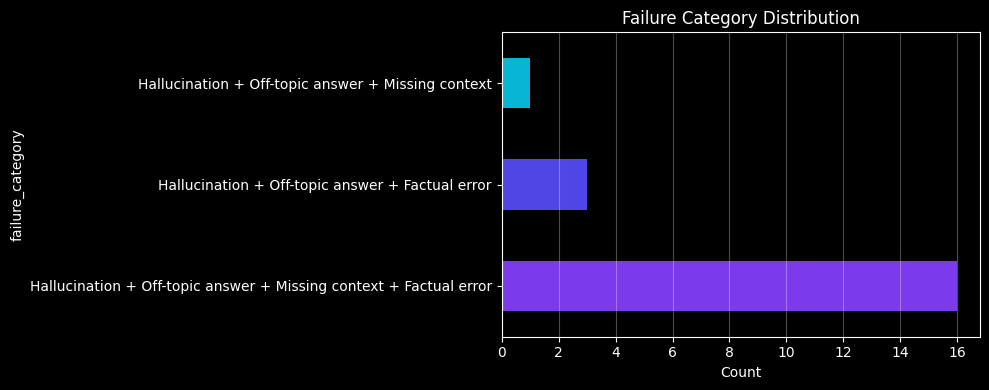

In [51]:
# ── Failure category attribution ───────────────────────────────────────
def failure_category(row):
    cats = []
    if row.get('faithfulness', 1) < 0.6:     cats.append('Hallucination')
    if row.get('answer_relevancy', 1) < 0.6: cats.append('Off-topic answer')
    if row.get('context_precision', 1) < 0.5: cats.append('Poor ranking')
    if row.get('context_recall', 1) < 0.5:   cats.append('Missing context')
    if row.get('answer_correctness', 1) < 0.6: cats.append('Factual error')
    return ' + '.join(cats) if cats else 'Borderline'

results_df['failure_category'] = results_df.apply(failure_category, axis=1)
cat_counts = results_df['failure_category'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
cat_counts.plot(kind='barh', ax=ax, color=PALETTE)
ax.set_title('Failure Category Distribution', fontsize=12)
ax.set_xlabel('Count')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 5 — Recommendations & Next Steps

In [52]:
report = evaluator.generate_report(results_df)
print('=== ACTIONABLE RECOMMENDATIONS ===')
for i, rec in enumerate(report['recommendations'], 1):
    print(f'  {i}. {rec}')

print('\n=== QUALITY TIER DISTRIBUTION ===')
for tier, count in report['summary']['quality_distribution'].items():
    pct = count / report['summary']['total_samples'] * 100
    print(f'  {tier:12s}: {count:3d} ({pct:.1f}%)')

=== ACTIONABLE RECOMMENDATIONS ===
  1. Low faithfulness: LLM hallucinating. Tighten system prompt with 'only use provided context'.
  2. Low answer relevancy: Answers drift off-topic. Add query intent classification.
  3. Low context recall: Missing relevant chunks. Increase chunk overlap or add BM25 fallback.
  4. Low answer correctness: Verify knowledge-base freshness and consider fine-tuning.

=== QUALITY TIER DISTRIBUTION ===
  fair        :  13 (65.0%)
  poor        :   7 (35.0%)


In [53]:
# ── Export results ─────────────────────────────────────────────────────
out_path = 'eval_results.csv'
results_df.to_csv(out_path, index=False)
print(f'Results saved to {out_path}')

Results saved to eval_results.csv
